# Plot data from the Yale LFHCal SiPM QA test bench
Emily Pottebaum, emily.pottebaum@yale.edu <br>
September 2025

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy as scp
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
import seaborn as sns
import os, sys
from glob import glob

In [2]:
# matplotlib parameters
mpl.rcParams['text.usetex'] = True
mpl.rcParams['mathtext.rm'] = 'Arial'
mpl.rcParams['mathtext.it'] = 'Arial:italic'
mpl.rcParams['mathtext.bf'] = 'Arial:bold'

mpl.rc('font', family='sans-serif', size=20)
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['xtick.major.size'] = 8
mpl.rcParams['ytick.major.size'] = 8

mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.linewidth'] = 1.2 # set the value globally

# mpl.rc('font', size=16)
mpl.rc('axes', titlesize=22)

mpl.rcParams['font.size'] = 20
mpl.rcParams['font.family'] = 'sans-serif'

current_palette = sns.color_palette('colorblind', 10)
import warnings
warnings.filterwarnings("ignore")

## Specify batch number:

In [5]:
batchnum = '250821'

In [6]:
# NOTE: Idark is in nA
IV_cols = ['run_name', 'sipm_id', 'temp_avg', 'temp_dev', 'Vpeak_raw', 'Vpeak_25C', 'Idark_m3V', 
           'Idark_p4V', 'temp_preIdark', 'fwd_res']
SPS_cols = ['sipm_id', 'num_peaks', 'fit_width', 'Vbd_raw', 'temp_avg', 'temp_err', 'Vbd_25C', 'Vbd_err',
            'chi2_red', 'p0mean', 'p1mean', 'idk']
IV_data = []
SPS_data = []
rootdir = './data/batch_' + batchnum + '/'
subdirs = next(os.walk(rootdir))[1] # get subdirectories for each tray
subdirs.sort() # sort numerically by tray number
print("My file structure:")
for dirname in subdirs:
    print(os.path.join(rootdir, dirname))
    iv_file = os.path.join(rootdir, dirname, 'IV_result.txt')
    sps_file = os.path.join(rootdir, dirname, 'SPS_result_onlynumbers.txt')
    iv_df = pd.read_csv(iv_file, skiprows=1, sep=r'\s+', names=IV_cols)
    IV_data.append(iv_df)
    sps_df = pd.read_csv(sps_file, sep=r'\s+', names=SPS_cols)
    SPS_data.append(sps_df)


My file structure:
./data/batch_250821/250821-1301-results
./data/batch_250821/250821-1302-results
./data/batch_250821/250821-1303-results
./data/batch_250821/250821-1304-results


## Sort by sipm_id in the same way for IV and SPS
Rows are ordered differently for IV vs SPS output because god forbid anything be convenient! Re-order the SPS dataframe according to the IV order (which is correct)

In [16]:
sipmorder = [IV_data[0]['sipm_id']]
for i in range(len(SPS_data)): # for each tray
    sipmorder = np.array(IV_data[i]['sipm_id'])
    SPS_data[i]['sipm_id'] = pd.Categorical(SPS_data[i]['sipm_id'], categories=sipmorder, ordered=True)
    SPS_data[i] = SPS_data[i].sort_values('sipm_id').reset_index()

In [17]:
IV_data[0].head()

,run_name,sipm_id,temp_avg,temp_dev,Vpeak_raw,Vpeak_25C,Idark_m3V,Idark_p4V,temp_preIdark,fwd_res
0,250821-1301-set0-full,250821-1301_0_0,23.344,0.033,38.2906,38.3469,0.5,11.2,23.34,118.16
1,250821-1301-set0-full,250821-1301_0_1,23.352,0.018,38.2721,38.3250,0.2,10.8,23.48,110.58
2,250821-1301-set1-full,250821-1301_0_2,23.242,0.003,38.2886,38.3482,0.8,10.4,23.27,116.92
3,250821-1301-set2-full,250821-1301_0_3,23.055,0.022,38.2995,38.3656,0.2,8.1,23.07,106.98
4,250821-1301-set2-full,250821-1301_0_4,23.066,0.028,38.2235,38.2861,0.8,10.5,23.23,112.81


In [18]:
SPS_data[0].head()

,level_0,index,sipm_id,num_peaks,fit_width,Vbd_raw,temp_avg,temp_err,Vbd_25C,Vbd_err,chi2_red,p0mean,p1mean,idk
0,0,0,250821-1301_0_0,4,400,37.7479,23.3507,0.001890,37.8040,0.016704,0.103625,-3505.47,92.8650,NaN
1,1,4,250821-1301_0_1,4,400,37.7022,23.6591,0.002268,37.7478,0.034219,0.110564,-3514.02,93.2038,NaN
2,2,12,250821-1301_0_2,4,400,37.7236,23.4069,0.004140,37.7778,0.014004,0.268684,-3488.79,92.4829,NaN
3,3,13,250821-1301_0_3,4,400,37.7396,23.1323,0.002138,37.8031,0.032085,0.086180,-3538.70,93.7659,NaN
4,4,14,250821-1301_0_4,4,400,37.6780,23.5857,0.005345,37.7261,0.015389,0.184745,-3477.24,92.2883,NaN


In [28]:
# get heatmaps showing Vpeak and Vbd for each SiPM in the tray
# tray oriented such that SiPM electrodes are pointing down (tray label at top left)
# ti = tray index (corresponds to the tray order in the dataframes)
def get_heatmaps_raw(ti):
    traylabel = SPS_data[ti]['sipm_id'][0].split('_')[0]
    
    Vpeak = np.array(IV_data[ti]['Vpeak_raw'])
    Vbd = np.array(SPS_data[ti]['Vbd_raw'])
    cols_peak = []
    cols_bd = []
    for i in range(0,23): # loop over columns
        thiscol_peak = []
        thiscol_bd = []
        colstart = int(i*20) # index from 0-459  for the start of this column
        for j in range(0,20): # loop over rows
            thiscol_peak.append(Vpeak[colstart+j])
            thiscol_bd.append(Vbd[colstart+j])
        cols_peak.append(thiscol_peak)
        cols_bd.append(thiscol_bd)
    df_peak = pd.DataFrame(np.array(cols_peak).T)
    df_bd = pd.DataFrame(np.array(cols_bd).T)
    
    
    # Make heatmap for Vpeak (from IV_data)
    plt.figure(figsize=(7,5))
    cmap = 'magma'
    
    # Uncomment the first "hm_peak = ..." to set the min and max values for the colorbar (z-axis)
    vpeakmin = 38.22
    vpeakmax = 38.36
#     hm_peak = sns.heatmap(df_peak, cmap=cmap, vmin=vpeakmin, vmax=vpeakmax, cbar_kws={'label': r'V\textsubscript{peak}', 'pad': 0.01})
    hm_peak = sns.heatmap(df_peak, cmap=cmap, cbar_kws={'label': r'V\textsubscript{peak}','pad': 0.01})

    
    hm_peak.figure.axes[-1].yaxis.label.set_size(16)
    plt.tick_params(labelrotation=0)
    plt.text(0,-1, r'\textbf{ePIC} Test Stand', fontsize=12)
    plt.text(0,-0.1, r'\textbf{Debrecen} SiPM Test Setup @ \textbf{Yale}', fontsize=12)
    sipmtraylabel = r'Hamamatsu \textbf{S14160-1315PS} Tray \#'+traylabel
    plt.text(23, -1, r'Hamamatsu \textbf{S14160-1315PS}', horizontalalignment='right', fontsize=12)
    plt.text(23, -0.1, 'Tray \#'+traylabel, horizontalalignment='right', fontsize=12)
    plt.xlabel('Column', loc='right', labelpad=3)
    plt.ylabel('Row', loc='top', labelpad=-5)
    plt.tight_layout();
    plt.savefig('plots/tray_heatmaps_raw/heatmaps_Vpeak_'+traylabel+'.pdf', bbox_inches='tight')
    
    
    
    # Make heatmap for Vbd (from SPS_data)
    plt.figure(figsize=(7,5))
    
    # Uncomment the first "hm_bdn = ..." to set the min and max values for the colorbar (z-axis)
    vbdmin = 37.63
    vbdmax = 37.82
#     hm_bdn = sns.heatmap(df_bd, cmap=cmap, vmin=vbdmin, vmax=vbdmax, cbar_kws={'label': r'V\textsubscript{BD}', 'pad': 0.01})
    hm_bdn = sns.heatmap(df_bd, cmap=cmap, cbar_kws={'label': r'V\textsubscript{BD}','pad': 0.01})
    
    
    hm_bdn.figure.axes[-1].yaxis.label.set_size(16)
    plt.tick_params(labelrotation=0)
    plt.text(0,-1, r'\textbf{ePIC} Test Stand', fontsize=12)
    plt.text(0,-0.1, r'\textbf{Debrecen} SiPM Test Setup @ \textbf{Yale}', fontsize=12)
    plt.text(23, -1, r'Hamamatsu \textbf{S14160-1315PS}', horizontalalignment='right', fontsize=12)
    plt.text(23, -0.1, 'Tray \#'+traylabel, horizontalalignment='right', fontsize=12)
    plt.xlabel('Column', loc='right', labelpad=3)
    plt.ylabel('Row', loc='top', labelpad=-5)
    plt.tight_layout();
    plt.savefig('plots/tray_heatmaps_raw/heatmaps_Vbd_'+traylabel+'.pdf', bbox_inches='tight')


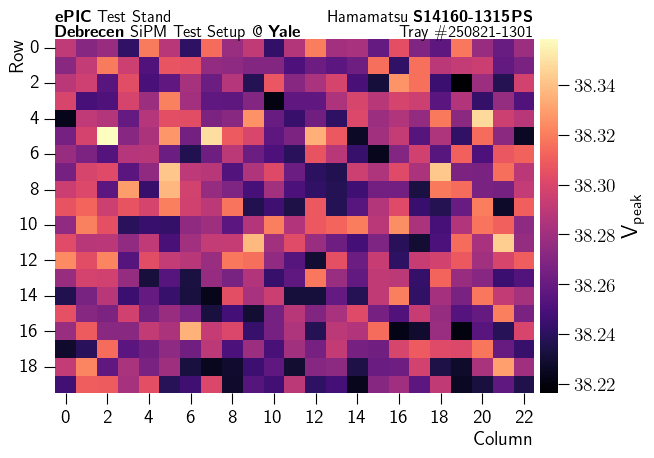

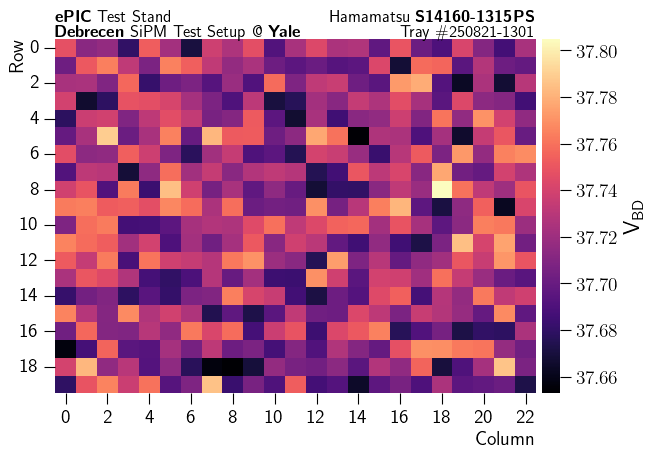

In [29]:
get_heatmaps_raw(0)

In [30]:
# get heatmaps showing Vpeak and Vbd, corrected to 25 C, for each SiPM in the tray
# tray oriented such that SiPM electrodes are pointing down (tray label at top left)
def get_heatmaps(ti):

    traylabel = SPS_data[ti]['sipm_id'][0].split('_')[0]

    Vpeak = np.array(IV_data[ti]['Vpeak_25C'])
    Vbd = np.array(SPS_data[ti]['Vbd_25C'])
    cols_peak = []
    cols_bd = []
    for i in range(0,23): # loop over columns
        thiscol_peak = []
        thiscol_bd = []
        colstart = int(i*20) # index from 0-459  for the start of this column
        for j in range(0,20): # loop over rows
            thiscol_peak.append(Vpeak[colstart+j])
            thiscol_bd.append(Vbd[colstart+j])
        cols_peak.append(thiscol_peak)
        cols_bd.append(thiscol_bd)
    df_peak = pd.DataFrame(np.array(cols_peak).T)
    df_bd = pd.DataFrame(np.array(cols_bd).T)
    
    
    # Make heatmap for Vpeak (from IV_data)
    plt.figure(figsize=(7,5))
    cmap = 'magma'
    
    # Uncomment the first "hm_peak = ..." to set the min and max values for the colorbar (z-axis)
    vpeakmin = 38.26
    vpeakmax = 38.4
    #hm_peak = sns.heatmap(df_peak, cmap=cmap, vmin=vpeakmin, vmax=vpeakmax, cbar_kws={'label': r'V\textsubscript{peak}(25$^{\circ}$C)', 'pad': 0.01})
    hm_peak = sns.heatmap(df_peak, cmap=cmap, cbar_kws={'label': r'V\textsubscript{peak}(25$^{\circ}$C)', 'pad': 0.01})
    
    
    hm_peak.figure.axes[-1].yaxis.label.set_size(16)
    plt.tick_params(labelrotation=0)
    plt.text(0,-1, r'\textbf{ePIC} Test Stand', fontsize=12)
    plt.text(0,-0.1, r'\textbf{Debrecen} SiPM Test Setup @ \textbf{Yale}', fontsize=12)
    sipmtraylabel = r'Hamamatsu \textbf{S14160-1315PS} Tray \#'+traylabel
    plt.text(23, -1, r'Hamamatsu \textbf{S14160-1315PS}', horizontalalignment='right', fontsize=12)
    plt.text(23, -0.1, 'Tray \#'+traylabel, horizontalalignment='right', fontsize=12)
    plt.xlabel('Column', loc='right', labelpad=3)
    plt.ylabel('Row', loc='top', labelpad=-5)
    plt.tight_layout();
    plt.savefig('plots/tray_heatmaps/heatmaps_Vpeak_'+traylabel+'.pdf', bbox_inches='tight')
    
    
    # Make heatmap for Vbd (from SPS_data)
    plt.figure(figsize=(7,5))
    
    # Uncomment the first "hm_bdn = ..." to set the min and max values for the colorbar (z-axis)
    vbdmin = 37.68
    vbdmax = 37.84
#     hm_bdn = sns.heatmap(df_bd, cmap=cmap, vmin=vbdmin, vmax=vbdmax, cbar_kws={'label': r'V\textsubscript{BD}(25$^{\circ}$C)', 'pad': 0.01})
    hm_bdn = sns.heatmap(df_bd, cmap=cmap, cbar_kws={'label': r'V\textsubscript{BD}(25$^{\circ}$C)','pad': 0.01})
    
    hm_bdn.figure.axes[-1].yaxis.label.set_size(16)
    plt.tick_params(labelrotation=0)
    plt.text(0,-1, r'\textbf{ePIC} Test Stand', fontsize=12)
    plt.text(0,-0.1, r'\textbf{Debrecen} SiPM Test Setup @ \textbf{Yale}', fontsize=12)
    plt.text(23, -1, r'Hamamatsu \textbf{S14160-1315PS}', horizontalalignment='right', fontsize=12)
    plt.text(23, -0.1, 'Tray \#'+traylabel, horizontalalignment='right', fontsize=12)
    plt.xlabel('Column', loc='right', labelpad=3)
    plt.ylabel('Row', loc='top', labelpad=-5)
    plt.tight_layout();
    plt.savefig('plots/tray_heatmaps/heatmaps_Vbd_'+traylabel+'.pdf', bbox_inches='tight')


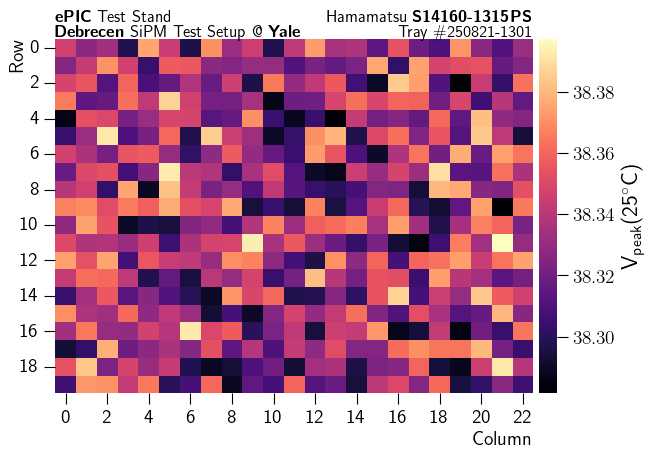

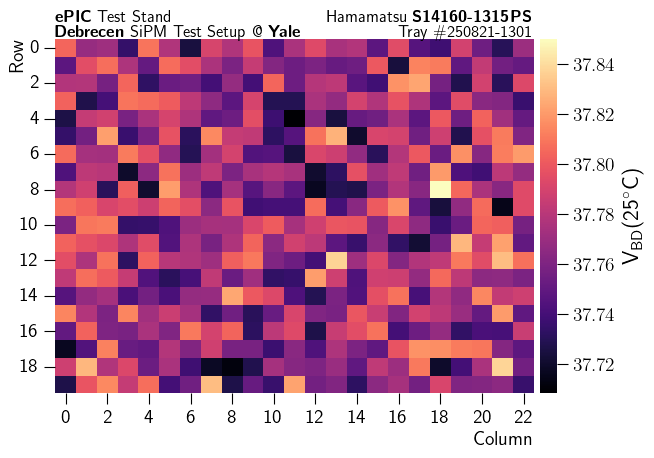

In [31]:
get_heatmaps(0)

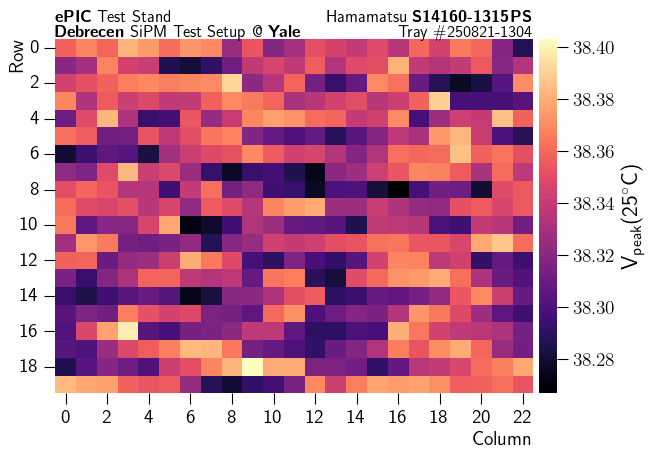

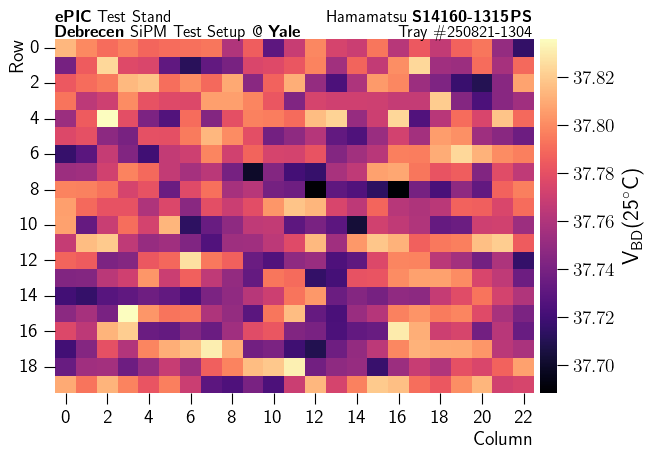

In [33]:
get_heatmaps(3)

In [42]:
# Plot Vbd against Vpeak
# ti = 0 # tray index (corresponds to the tray order in the dataframes)
def plot_vcorr(ti):

    traylabel = SPS_data[ti]['sipm_id'][0].split('_')[0]
    
    fig, ax = plt.subplots(figsize=(7,5))
    plt.scatter(IV_data[ti]['Vpeak_raw'], SPS_data[ti]['Vbd_raw']);
    plt.ylim(37.6, 37.9)
    plt.xlim(38.21, 38.37)
    m10, b10, r10, p10, std10 = linregress(IV_data[ti]['Vpeak_raw'], SPS_data[ti]['Vbd_raw'])
    linreglabel0 = r'$V_{BD} = $' + str(round(m10,2))+r'$V_{peak}$ + ' + str(round(b10,2))
    plt.plot(IV_data[ti]['Vpeak_raw'], m10*IV_data[ti]['Vpeak_raw']+b10, color='red', 
               label=linreglabel0)   
    vpeak_mean0 = np.mean(np.array(IV_data[ti]['Vpeak_raw']))
    vbd_mean0 = np.mean(np.array(SPS_data[ti]['Vbd_raw']))
    vpeaklabel0 = r'$\widehat{V}_{peak}$='+str(round(vpeak_mean0,2))+r' $\pm$ 0.05 V'
    vbdlabel0 = r'$\widehat{V}_{BD}$='+str(round(vbd_mean0,2))+r'$ \pm$ 0.05 V'
    boxlabel0 = vpeaklabel0 + '\n' + vbdlabel0
    boxlabel0 = r'SiPMs within $\widehat{V}_{peak} \pm 50 mV$, $\widehat{V}_{BD} \pm 50 mV$' 
    rect0 = mpl.patches.Rectangle((vpeak_mean0-0.05, vbd_mean0-0.05), 0.1, 0.1, 
                                   color='black', ls='--', fc='none', 
                                  label=boxlabel0)
    ax.add_patch(rect0)
    plt.legend(loc='upper left', fontsize=16, frameon=False, labelspacing=1)
    plt.text(38.27, 37.615, r'$\widehat{V}_{peak}$: ' + str((round(vpeak_mean0,2)))+' V,', color='black')
    plt.text(38.32, 37.615, r'$\widehat{V}_{BD}$: ' + str((round(vbd_mean0,2)))+' V', color='black')

    ax.text(38.21,37.923, r'\textbf{ePIC} Test Stand', fontsize=14)
    ax.text(38.21,37.905, r'\textbf{Debrecen} SiPM Test Setup @ \textbf{Yale}', fontsize=14)
    ax.text(38.37, 37.923, r'Hamamatsu \textbf{S14160-1315PS}', horizontalalignment='right', fontsize=14)
    ax.text(38.37, 37.905, 'Tray \#'+traylabel, horizontalalignment='right', fontsize=14)
    plt.xlabel(r'V\textsubscript{peak}', loc='right', labelpad=3)
    plt.ylabel(r'V\textsubscript{BD}', loc='top', labelpad=1)
    plt.tight_layout();
#     plt.savefig('plots/v_correlation/Vcorr_raw_'+traylabel+'.pdf', bbox_inches='tight')
    
    
    
    # get outliers
    print("Tray", traylabel)
    print("Raw data")
    vpeak_min0 = vpeak_mean0-0.05
    vpeak_max0 = vpeak_mean0+0.05
    test00 = IV_data[ti][(IV_data[ti]['Vpeak_raw']>vpeak_min0) & (IV_data[ti]['Vpeak_raw']<vpeak_max0)]
    peakol0 = len(IV_data[ti])-len(test00)
    print("Vpeak outliers (IV):", peakol0, "("+str(round(peakol0/460.*100,2))+"%)")
    vbd_min0 = vbd_mean0-0.05
    vbd_max0 = vbd_mean0+0.05
    test01 = SPS_data[ti][(SPS_data[ti]['Vbd_raw']>vbd_min0) & (SPS_data[ti]['Vbd_raw']<vbd_max0)]
    bdol0 = len(SPS_data[ti]) - len(test01)
    print("Vbd outliers (SPS):", bdol0, "("+str(round(bdol0/460.*100,2))+"%)")
    
    
    fig, ax = plt.subplots(figsize=(7,5))
    plt.scatter(IV_data[ti]['Vpeak_25C'], SPS_data[ti]['Vbd_25C']);
    m11, b11, r11, p11, std11 = linregress(IV_data[ti]['Vpeak_25C'], SPS_data[ti]['Vbd_25C'])
    linreglabel1 = r'$V_{BD} = $' + str(round(m11,2))+r'$V_{peak}$ + ' + str(round(b11,2))
    plt.plot(IV_data[ti]['Vpeak_25C'], m11*IV_data[ti]['Vpeak_25C']+b11, color='red', label=linreglabel1)
    plt.xlim(38.27, 38.41)
    plt.ylim(37.6, 37.9)
    
    vpeak_mean1 = np.mean(np.array(IV_data[ti]['Vpeak_25C']))
    vbd_mean1 = np.mean(np.array(SPS_data[ti]['Vbd_25C']))
    vpeaklabel1 = r'$\widehat{V}_{peak}$='+str(round(vpeak_mean1,2))+r' $\pm$ 0.05 V'
    vbdlabel1 = r'$\widehat{V}_{BD}$='+str(round(vbd_mean1,2))+r'$ \pm$ 0.05 V'
    boxlabel1 = vpeaklabel1 + '\n' + vbdlabel1
    boxlabel1 = r'SiPMs within $\widehat{V}_{peak} \pm 50 mV$, $\widehat{V}_{BD} \pm 50 mV$' 
    rect1 = mpl.patches.Rectangle((vpeak_mean1-0.05, vbd_mean1-0.05), 0.1, 0.1, 
                                   color='black', ls='--', fc='none', 
                                  label=boxlabel1)
    ax.add_patch(rect1)
    
    ax.legend(loc='lower right', fontsize=16, frameon=False, labelspacing=1)
    ax.text(38.275, 37.87, r'$\widehat{V}_{peak}$: ' + str((round(vpeak_mean1,2)))+' V,', color='black')
    ax.text(38.32, 37.87, r'$\widehat{V}_{BD}$: ' + str((round(vbd_mean1,2)))+' V', color='black')
    
    ax.text(38.27, 37.923, r'\textbf{ePIC} Test Stand', fontsize=14)
    ax.text(38.27, 37.905, r'\textbf{Debrecen} SiPM Test Setup @ \textbf{Yale}', fontsize=14)
    ax.text(38.41, 37.923, r'Hamamatsu \textbf{S14160-1315PS}', horizontalalignment='right', fontsize=14)
    ax.text(38.41, 37.905, 'Tray \#'+traylabel, horizontalalignment='right', fontsize=14)
    plt.xlabel(r'V\textsubscript{peak}(25$^{\circ}$C)', loc='right', labelpad=3)
    plt.ylabel(r'V\textsubscript{BD}(25$^{\circ}$C)', loc='top', labelpad=1)
    plt.tight_layout();
#     plt.savefig('plots/v_correlation/Vcorr_25C_'+traylabel+'.pdf', bbox_inches='tight')
    
    
    # get outliers
    print()
    print("Tray", traylabel)
    print("Corrected data")
    vpeak_min1 = vpeak_mean1-0.05
    vpeak_max1 = vpeak_mean1+0.05
    test01 = IV_data[ti][(IV_data[ti]['Vpeak_25C']>vpeak_min1) & (IV_data[ti]['Vpeak_25C']<vpeak_max1)]
    peakol1 = len(IV_data[ti])-len(test01)
    print("Vpeak outliers (IV):", peakol1, "("+str(round(peakol1/460.*100,2))+"%)")
    vbd_min1 = vbd_mean1-0.05
    vbd_max1 = vbd_mean1+0.05
    test11 = SPS_data[ti][(SPS_data[ti]['Vbd_25C']>vbd_min1) & (SPS_data[ti]['Vbd_25C']<vbd_max1)]
    bdol1 = len(SPS_data[ti]) - len(test11)
    print("Vbd outliers (SPS):", bdol1, "("+str(round(bdol1/460.*100,2))+"%)")
    

Tray 250821-1301
Raw data
Vpeak outliers (IV): 25 (5.43%)
Vbd outliers (SPS): 36 (7.83%)

Tray 250821-1301
Corrected data
Vpeak outliers (IV): 14 (3.04%)
Vbd outliers (SPS): 24 (5.22%)


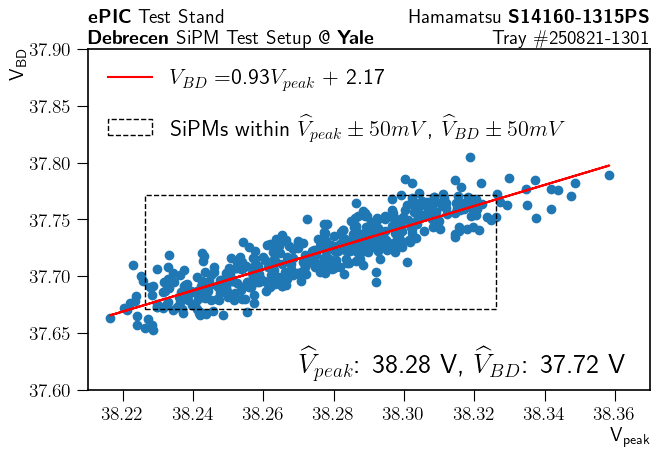

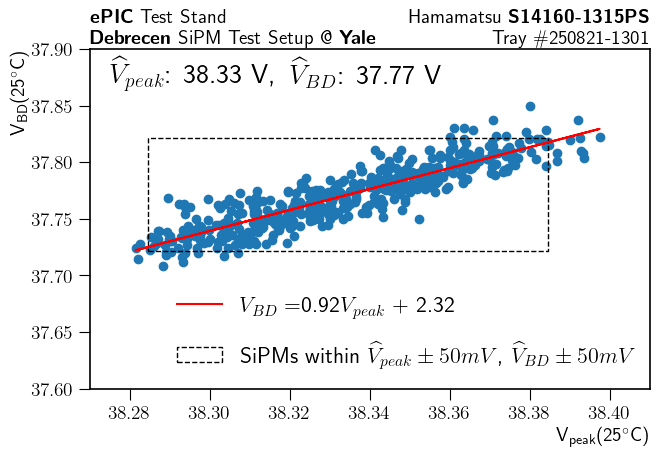

In [46]:
plot_vcorr(0)